#2 Getting Started with Image Processing with Python.

Introduction to Python Imaging Library(PIL)



2.1 Exercise - 1:

Complete all the Task.

1. Read and display the image.

• Read the image using the Pillow library and display it.

• You can also use matplotlib to display the image.

In [ ]:
# Import required libraries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

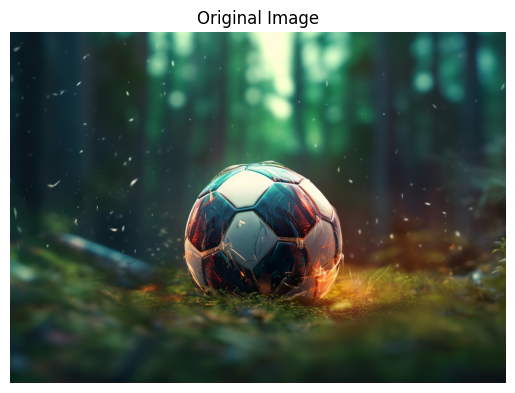

In [ ]:
# Open image (replace with your image path)
image = Image.open("/content/drive/MyDrive/ArtificialIntelligenceandMachineLearning/week1/football.jpg")

# Convert to numpy array
image_array = np.array(image)

# Display using matplotlib
plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")
plt.show()


2. Display only the top left corner of 100x100 pixels.

• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.

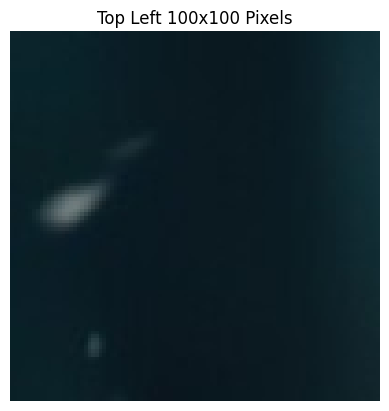

In [ ]:
top_left = image_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

3. Show the three color channels (R, G, B).

• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

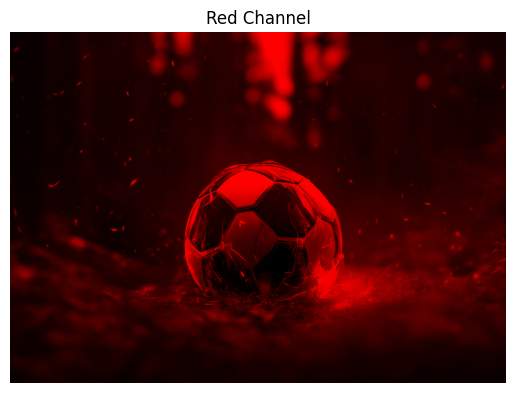

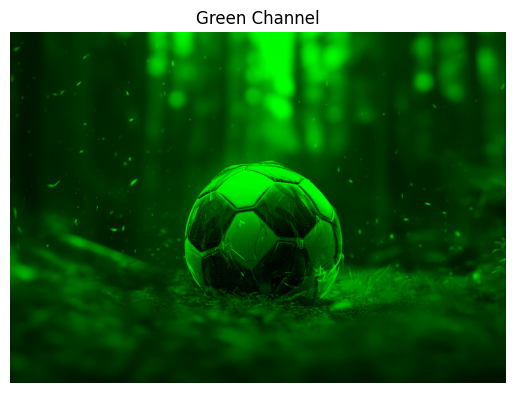

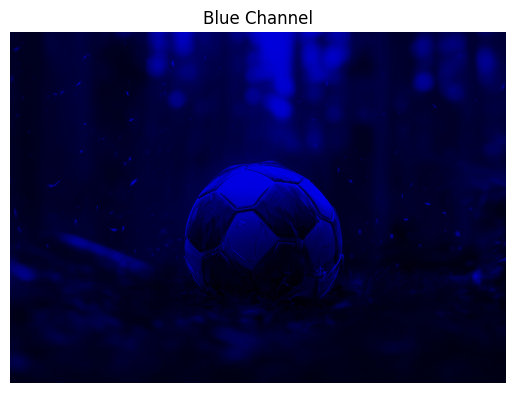

In [ ]:
# Create empty arrays (same shape as original)
red_channel = image_array.copy()
green_channel = image_array.copy()
blue_channel = image_array.copy()

# Zero out unwanted channels

# Red image
red_channel[:, :, 1] = 0
red_channel[:, :, 2] = 0

# Green image
green_channel[:, :, 0] = 0
green_channel[:, :, 2] = 0

# Blue image
blue_channel[:, :, 0] = 0
blue_channel[:, :, 1] = 0


# Display them
plt.imshow(red_channel)
plt.title("Red Channel")
plt.axis("off")
plt.show()

plt.imshow(green_channel)
plt.title("Green Channel")
plt.axis("off")
plt.show()

plt.imshow(blue_channel)
plt.title("Blue Channel")
plt.axis("off")
plt.show()

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

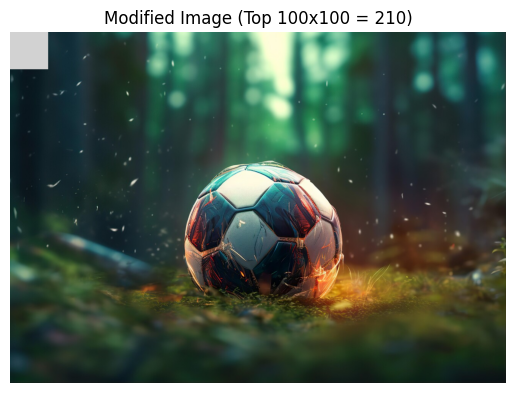

In [ ]:
# Make a copy so original stays unchanged
modified_image = image_array.copy()

# Set top-left 100x100 region to 210 (light gray)
modified_image[0:100, 0:100] = 210

plt.imshow(modified_image)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

#2.2 Exercise - 2:

Complete all the Task.

1. Load and display a grayscale image.

• Load a grayscale image using the Pillow library.

• Display the grayscale image using matplotlib.

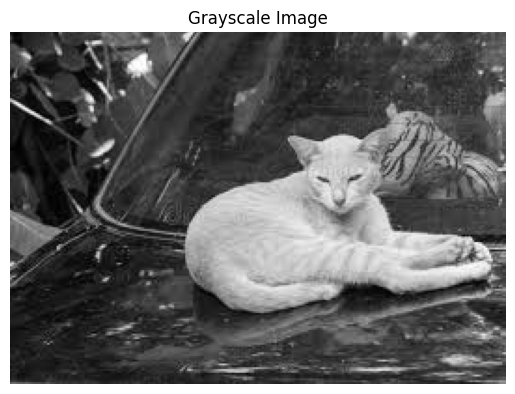

In [ ]:
# -----------------------------------------
# 1. Load and Display Grayscale Image
# -----------------------------------------

# Open image and convert to grayscale
image = Image.open("/content/drive/MyDrive/ArtificialIntelligenceandMachineLearning/week1/cat.jpg").convert("L")

# Convert to numpy array
gray_array = np.array(image)

# Display grayscale image
plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

2. Extract and display the middle section of the image (150 pixels).

• Extract a 150 pixel section from the center of the image using NumPy array slicing.

• Display this cropped image using matplotlib.

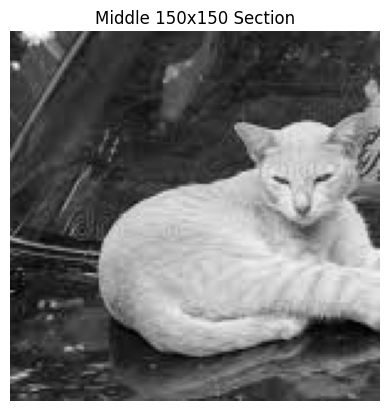

In [ ]:
height, width = gray_array.shape

# Find center
center_y = height // 2
center_x = width // 2

# Extract 150x150 region around center
middle_section = gray_array[
    center_y - 75 : center_y + 75,
    center_x - 75 : center_x + 75
]

plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).

• Display the resulting binary image.

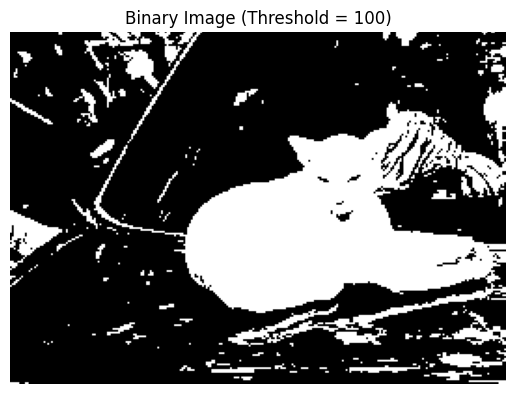

In [ ]:
binary_image = gray_array.copy()

# Apply threshold
binary_image[binary_image < 100] = 0
binary_image[binary_image >= 100] = 255

plt.imshow(binary_image, cmap="gray")
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.

• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.

• Display the rotated image using matplotlib.

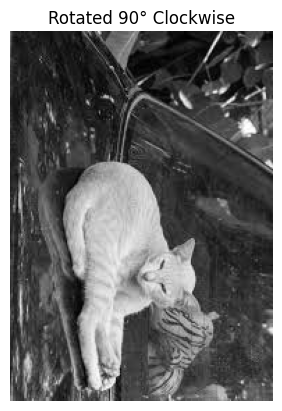

In [ ]:
rotated_image = image.rotate(-90, expand=True)

plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated 90° Clockwise")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).

• Display the converted RGB image using matplotlib.

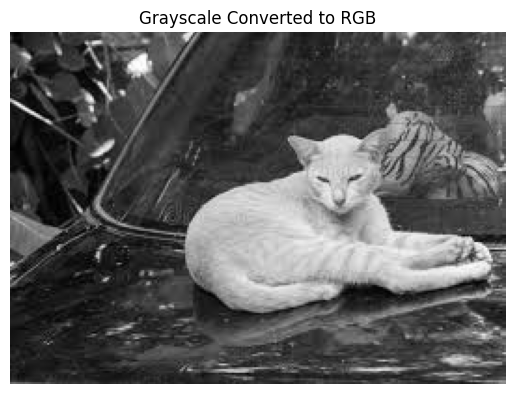

In [ ]:
rgb_image = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

1. Load and Prepare Data:

• Fetch an image of you choice.{If colour convert to grayscale}

• Center the dataset - Standaridze the Data.

• Calculate the covaraince matrix of the Standaridze data.

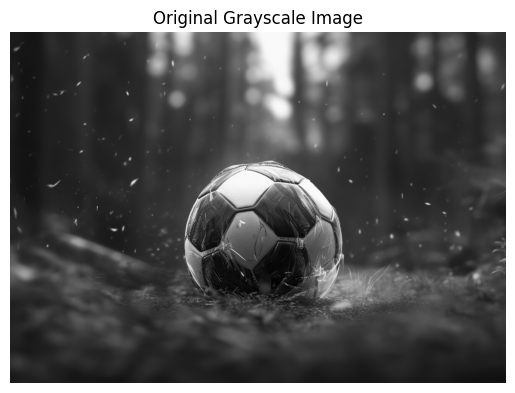

Covariance Matrix Shape: (1300, 1300)


In [ ]:
# Load image and convert to grayscale
image = Image.open("/content/drive/MyDrive/ArtificialIntelligenceandMachineLearning/week1/football.jpg").convert("L")
img_array = np.array(image, dtype=np.float64)

plt.imshow(img_array, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

# Standardize (Mean Centering)
mean = np.mean(img_array, axis=0)
X_centered = img_array - mean

# Covariance Matrix
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance Matrix Shape:", cov_matrix.shape)

2. Eigen Decomposition and Identifying Principal Components:

• Compute Eigen Values and Eigen Vectors.

• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.

• Identify the Principal Components with the help of cumulative Sum plot.

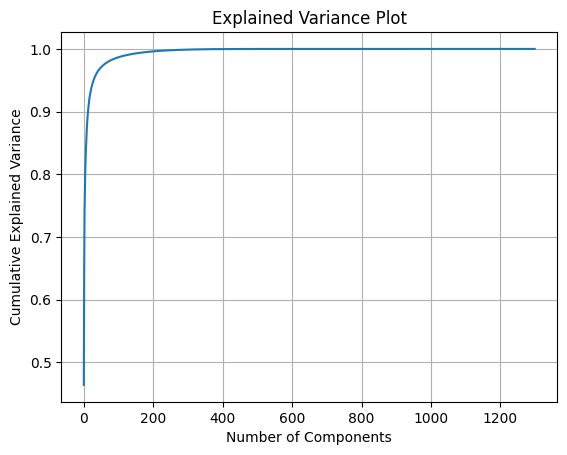

In [ ]:
# Eigen values and vectors
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
sorted_index = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_index]
eigen_vectors = eigen_vectors[:, sorted_index]

# Explained variance ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

• Display the Results and Evaluate.

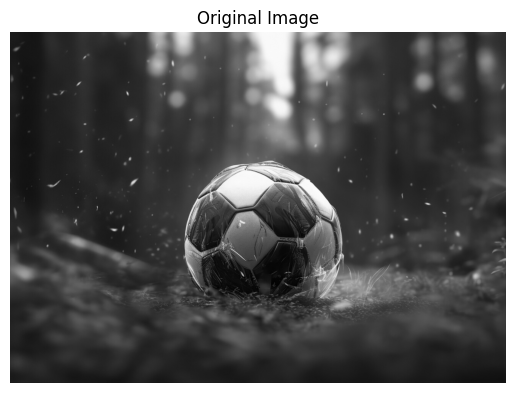

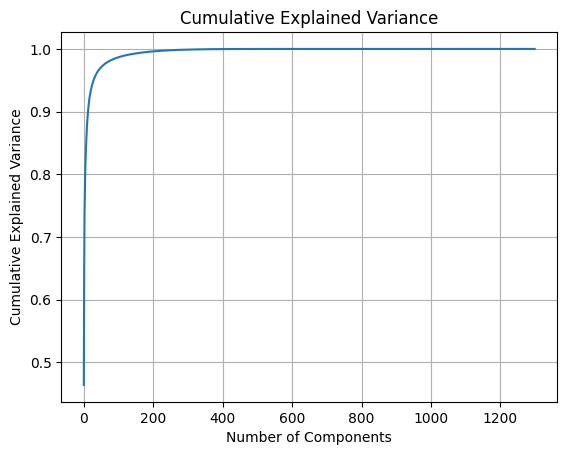

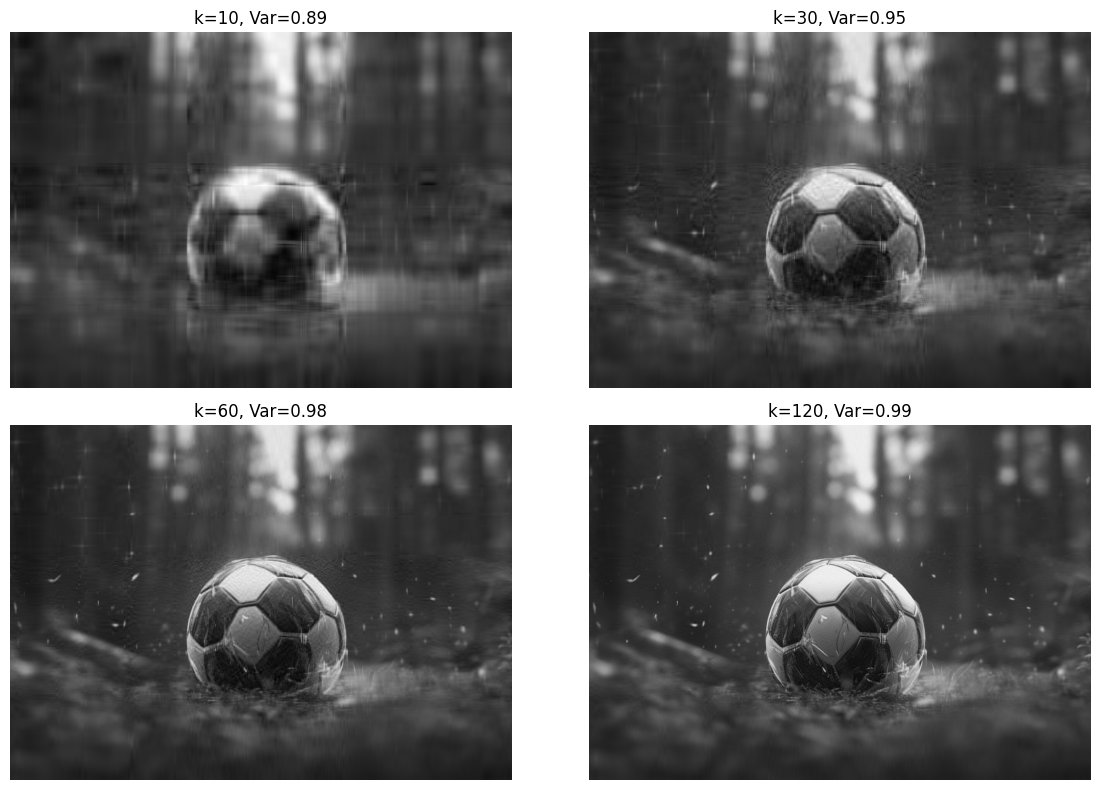

In [ ]:
def reconstruct(k):
    P = eigen_vectors[:, :k]
    Z = np.dot(X_centered, P)
    X_reconstructed = np.dot(Z, P.T) + mean
    return X_reconstructed

# Original Image
plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

# Cumulative Variance Plot
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid()
plt.show()

# 4 Reconstructions
k_values = [10, 30, 60, 120]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):
    recon = reconstruct(k)

    plt.subplot(2,2,i+1)
    plt.imshow(recon, cmap='gray')
    plt.title(f"k={k}, Var={cumulative_variance[k]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()